<a href="https://colab.research.google.com/github/KonetiSanjana725/Sentiment-Analysis-using-LSTM-model/blob/main/IDMB_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow

In [ ]:
!pip install nltk
!pip install bs4

In [ ]:
import nltk
import pandas as pd
import numpy as np
import tensorflow as tf
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
import string
from nltk.stem import WordNetLemmatizer,PorterStemmer

In [ ]:
#downloading nltk packages
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
data=pd.read_csv("/content/IMDB Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df=data.dropna()
df.shape

(50000, 2)

In [ ]:
data.shape

(50000, 2)

In [ ]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


**DATA** **PREPROCESSING**

In [ ]:
punctuation=string.punctuation
stopwords=nltk.corpus.stopwords.words('english')
lm=WordNetLemmatizer()

In [ ]:
text=df['review'][1]
text

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

In [ ]:
BeautifulSoup(text,'html.parser').get_text()

'A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well done.'

In [ ]:
def clean_text(text):
  only_text=BeautifulSoup(text,'html.parser').get_text()
  text="".join([char.lower() for char in only_text if char not in punctuation])
  tokens=word_tokenize(text)
  final_text=" ".join([lm.lemmatize(word) for word in tokens if word not in stopwords])
  return final_text

In [ ]:
clean_text(df['review'][1])

'wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen got polari voice pat truly see seamless editing guided reference williams diary entry well worth watching terrificly written performed piece masterful production one great master comedy life realism really come home little thing fantasy guard rather use traditional dream technique remains solid disappears play knowledge sens particularly scene concerning orton halliwell set particularly flat halliwells mural decorating every surface terribly well done'

In [ ]:
X=df['review'].apply(lambda x:clean_text(x))
X

,review
0,one reviewer mentioned watching 1 oz episode y...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically there family little boy jake think t...
4,petter matteis love time money visually stunni...
...,...
49995,thought movie right good job wasnt creative or...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,catholic taught parochial elementary school nu...
49998,im going disagree previous comment side maltin...


In [ ]:
Y=df['sentiment'].apply(lambda x: 1 if x=='positive' else 0)
Y

,sentiment
0,1
1,1
2,1
3,0
4,1
...,...
49995,1
49996,0
49997,0
49998,0


SPLIT DATA IN TRAINING AND TEST SET

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25)

In [ ]:
X_train.shape,Y_train.shape

((37500,), (37500,))

In [ ]:
X_test.shape,Y_test.shape

((12500,), (12500,))

In [ ]:
X_train

,review
38717,marquis de sade egyptian archaeology mermaid w...
26726,mate chose watch obvious piece junk purely bas...
846,first point really enjoyed watching documentar...
6672,sigh im baffled see short like get attention a...
49493,abysmal pulp adventure exploitation jungle wom...
...,...
14054,never read much even seen still sixman british...
35771,dragged movie four year ago french actress fri...
45004,even though book wasnt strictly accurate real ...
1648,nose bent slightly shape write sent previous c...


In [ ]:
Y_train

,sentiment
38717,1
26726,0
846,1
6672,0
49493,0
...,...
14054,1
35771,1
45004,0
1648,0


In [ ]:
#average number of tokens present in dataset
sum=0
for i in X.to_list():
  sum+=len(i.split(" "))
  avg=sum/len(X.to_list())
avg

119.84288

TEXT VECTORIZATION

In [ ]:
from tensorflow.keras.layers import TextVectorization

In [ ]:
vocab_size=20000
max_len=200
vectorize_layer=TextVectorization(
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=max_len
)
#building vocabulary
vectorize_layer.adapt(X_train)

In [ ]:
vocab=np.array(vectorize_layer.get_vocabulary())
vocab[:50]

array(['', '[UNK]', 'movie', 'film', 'one', 'like', 'time', 'good',
       'character', 'get', 'even', 'would', 'story', 'see', 'make',
       'really', 'scene', 'much', 'well', 'people', 'great', 'bad',
       'also', 'show', 'first', 'way', 'dont', 'thing', 'made', 'could',
       'think', 'life', 'go', 'know', 'watch', 'love', 'many', 'seen',
       'actor', 'plot', 'never', 'two', 'say', 'look', 'acting', 'end',
       'little', 'best', 'year', 'ever'], dtype='<U17')

Applying vectorization on training set

In [ ]:
vectorize_training_set=vectorize_layer(X_train)

In [ ]:
vectorize_training_set.shape

TensorShape([37500, 200])

In [ ]:
vectorize_training_set

<tf.Tensor: shape=(37500, 200), dtype=int64, numpy=
array([[ 8024,   757, 11441, ..., 17899,     1,     1],
       [ 2760,  2261,    34, ...,   730,   265,   884],
       [   24,    86,    15, ...,     0,     0,     0],
       ...,
       [   10,    73,   147, ...,     0,     0,     0],
       [ 2534,  5063,   925, ...,     0,     0,     0],
       [  866,  1989,   351, ...,   218,  1241,     1]])>

In [ ]:
X_train.to_list()[2]

'first point really enjoyed watching documentary great music shot editing also wonderful however positive thing film change fact play orientalist east meet west cliché bother many turk like okay film tell story traditional contemporary turkish music stylish manner good thing something would show ignorant european american country murdering armenian kurd however problematic film look defines east eye west mean like one jazz musician say film maybe east west maybe myth lie created ruling leader western country order keep fear hostility alive could continue ruling world keep cash flowing dont think'

In [ ]:
vectorize_training_set[2,:]

<tf.Tensor: shape=(200,), dtype=int64, numpy=
array([   24,    86,    15,   392,    67,   463,    20,   121,   136,
         688,    22,   294,   117,   961,    27,     3,   366,    93,
          71,     1,  2328,   376,  1096,  1390,  1006,    36, 16660,
           5,   732,     3,   167,    12,  1918,  1880,  3973,   121,
        2824,  1171,     7,    27,    60,    11,    23,  4179,  1575,
         173,   464,  4871,     1,     1,   117, 10042,     3,    43,
        8902,  2328,   245,  1096,   178,     5,     4,  3477,  2647,
          42,     3,   191,  2328,  1096,   191,  4020,   964,   895,
       12516,  1424,   632,   464,   467,   190,   833, 12957,  1004,
          29,  1519, 12516,    87,   190,  1968,  6473,    26,    30,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,   

In [ ]:
np.where(vocab=='evening')

(array([1966]),)

BUILDING EMBEDDING LAYER

In [ ]:
from tensorflow.keras.layers import Embedding
embed=Embedding(
    input_dim=len(vocab),
    output_dim=100
)

In [ ]:
embed(vectorize_training_set[2,:])

<tf.Tensor: shape=(200, 100), dtype=float32, numpy=
array([[ 0.02795437,  0.04293008, -0.00082978, ..., -0.00326048,
        -0.01461928,  0.04292974],
       [-0.01580248,  0.01036416, -0.00592647, ...,  0.04401923,
         0.01614222,  0.03469786],
       [-0.01994821, -0.04567468, -0.03375494, ..., -0.01344202,
         0.02307005, -0.0011332 ],
       ...,
       [-0.02614671, -0.01234848,  0.04773727, ..., -0.04498997,
        -0.03938211,  0.03924752],
       [-0.02614671, -0.01234848,  0.04773727, ..., -0.04498997,
        -0.03938211,  0.03924752],
       [-0.02614671, -0.01234848,  0.04773727, ..., -0.04498997,
        -0.03938211,  0.03924752]], dtype=float32)>

BUILDING LSTM MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import LSTM,Dense,Dropout, GlobalAveragePooling1D
model=Sequential()

model.add(Input(shape=(1,),dtype=tf.string))
model.add(vectorize_layer)
model.add(Embedding(input_dim=vocab_size,output_dim=100))
model.add(GlobalAveragePooling1D())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,006,529 (7.65 MB)

 Trainable params: 2,006,529 (7.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

MODEL TRAINING

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights= True
)
history=model.fit(X_train.to_numpy(),Y_train,validation_data=(X_test.to_numpy(),Y_test),batch_size=32,epochs=10,callbacks=[early_stop])

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8014 - loss: 0.4187 - val_accuracy: 0.8819 - val_loss: 0.2867
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.8984 - loss: 0.2567 - val_accuracy: 0.8642 - val_loss: 0.3105
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9223 - loss: 0.2084 - val_accuracy: 0.8810 - val_loss: 0.2956
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9338 - loss: 0.1808 - val_accuracy: 0.8294 - val_loss: 0.4428
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - accuracy: 0.9403 - loss: 0.1606 - val_accuracy: 0.8513 - val_loss: 0.4119
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.9480 - loss: 0.1412 - val_accuracy: 0.8801 - val_loss: 0.3489


In [ ]:
model.save("./Sentiment_Classifier_v1.keras")

**ACCURACY VISUALIZATION**

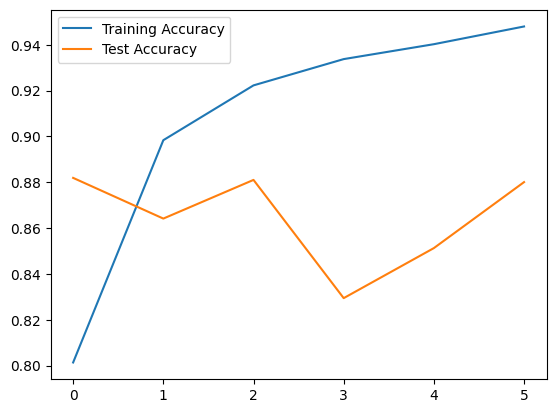

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Test Accuracy')
plt.legend()
plt.show()

In [ ]:
model=tf.keras.models.load_model("./Sentiment_Classifier_v1.keras")

**TESTING MODEL ON RANDOM TEXT**

In [ ]:
random_text="The movie was very good and the animations is so cool."
prediction=model.predict(tf.constant([random_text]))
if (prediction>0.5):
  print("Positive Sentiment","\nScore:",prediction[0][0])
else :
  print("Negative Sentiment","\nScore:",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Positive Sentiment 
Score: 0.51010466


In [ ]:
random_text="the movie was worst."
prediction=model.predict(tf.constant([random_text]))
if (prediction>0.5):
  print("Positive Sentiment","\nScore:",prediction[0][0])
else :
  print("Negative Sentiment","\nScore:",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Negative Sentiment 
Score: 0.20019488


**MODEL EVALUATION**

*   PRECISION
*   F1 SCORE
*   RECALL
*   CONFUSION MATRIX





In [ ]:
type(X_test)

pandas.core.series.Series

In [ ]:
y_pred=model.predict(tf.constant(X_test.to_list()))
y_pred_binary=np.where(y_pred>0.5,1,0)
y_pred_binary

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([[1],
       [0],
       [1],
       ...,
       [0],
       [1],
       [0]])

In [ ]:
y_pred_binary.shape

(12500, 1)

In [ ]:
y_true=np.array([Y_test.to_list()]).T
y_true.shape

(12500, 1)

COMPUTING PRECISION,RECALL,F1 SCORE

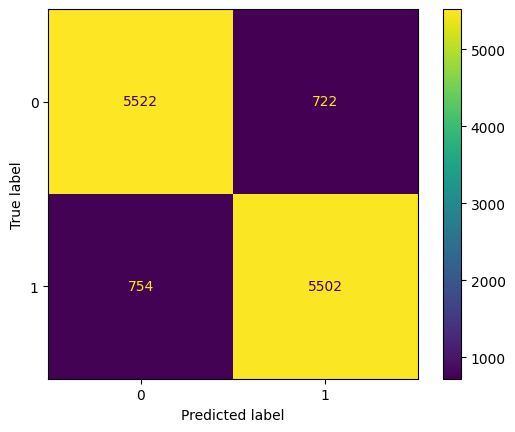

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(confusion_matrix(y_true,y_pred_binary))
disp.plot()


In [ ]:
print(classification_report(y_true,y_pred_binary))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      6244
           1       0.88      0.88      0.88      6256

    accuracy                           0.88     12500
   macro avg       0.88      0.88      0.88     12500
weighted avg       0.88      0.88      0.88     12500

